# Session 2: Attention Mechanism and Transformers

Welcome to the second practical session on LLM module. 
In this session, we will explore how to build from scratch the attention mechanism and transformer architecture, which are fundamental components of LLMs. This session is divided into:
1. **Attention Mechanism**: We will implement the attention mechanism step-by-step, understanding how it allows models to focus on different parts of the input sequence when making predictions.
2. **Transformer Architecture (TODO)**: We will build a simple transformer model, learning about its components such as multi-head attention and feed-forward networks.


During the whole session, we will use PyTorch. **No GPU is required as nothing will be trained at all.**

---

Good resources to learn more about attention and transformers:
- Blog posts:
    - [The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)
    - [Generalized language Models](https://lilianweng.github.io/posts/2019-01-31-lm/)
    - [Deep Learning Focus - Decoder Only](https://cameronrwolfe.substack.com/p/decoder-only-transformers-the-workhorse)
- Videos:
    - [Let's build GPT from scratch - Andrej Kaparthy](https://youtu.be/kCc8FmEb1nY?si=oS7TmIyyFHXqflrf)


# 0. Installation and Setup

For this lab, you will need to have Python and PyTorch installed.

In [1]:
#!pip install torch numpy

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(39) # For reproducibility

# 1. Self-Attention Mechanism - Basics with an example

Self-attention is a mechanism that allows a model to determine which other tokens are relevant when computing the representation of a particular token. Rather than considering only nearby tokens, a token can attend to other tokens in the sequence and assign them different importance weights.

Each token representation is projected into three vectors:

- **Query (Q)**: what this token is looking for.
- **Key (K)**: what this token offers for matching.
- **Value (V)**: the information this token can contribute.

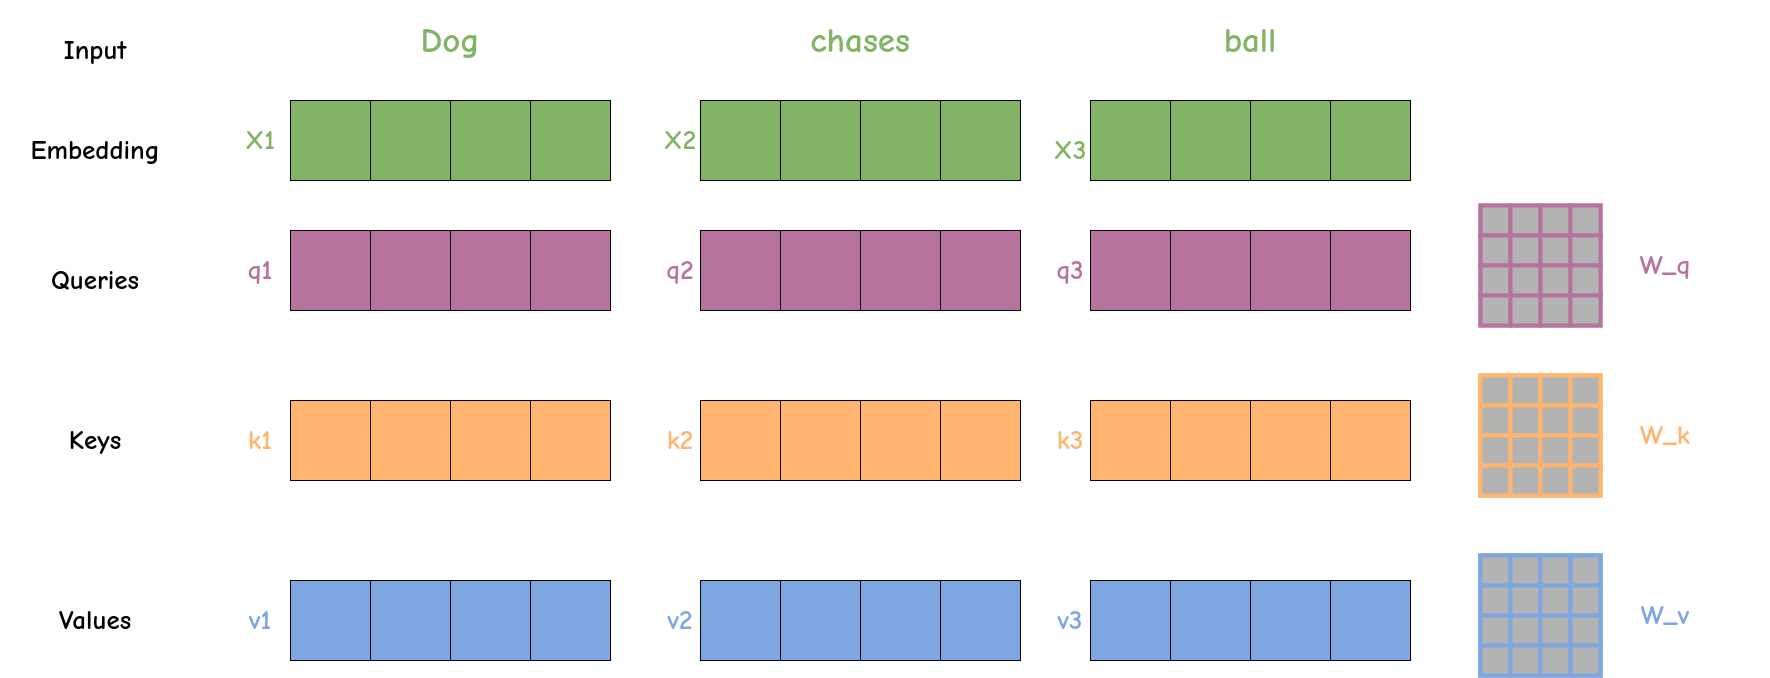

EXAMPLE:
- We focus on the word "chases". Its **query** is "Which tokens are relevant to understanding me?"
- Who are the **keys** i.e., who is relevant? 
    - "Dog" -> "I'm a noun! I might be useful for understanding 'chases'."
    - "ball" -> "I'm a noun! I might be useful for understanding 'chases'."
- Attention = **queries** and **keys**. 
- 🟧❓: What about "Ball chases dog" ?
- Value i.e., "in case I'm relevant this is the information you get from me"
    - "Dog" -> "I'm a four-legged animal that barks"
    - "ball" -> "I'm a round object that can be thrown or kicked"
---

How it works:
1. Starts with **input embeddings** for each word in a sentence.
2. Three different **weight matrices** are created / learned during training: W_q (for queries), W_k (for keys), and W_v (for values).
3. Each embedding is **multiplied** by W_q, W_k, W_v to produce the query, key, and value vectors. This is called a **linear projection**.
4. The query, key, and value vectors are then used to compute **attention scores**.

Example:  
Multiplying x1 by the W_q weight matrix produces q1, the query vector associated with that word.  
We end up creating a query, a key, and a value projection of each word in the input sentence.

---

In [3]:
# 1) Create input embeddings for 3 tokens of dimension d

seq_len = 3     # number of tokens
embed_dim = 4   # d

X1 = torch.randn(embed_dim)
X2 = torch.randn(embed_dim)
X3 = torch.randn(embed_dim)

print(f"X1: {X1} with shape {X1.shape}")
print(f"X2: {X2} with shape {X2.shape}")
print(f"X3: {X3} with shape {X3.shape}")
print()

# Stack into a single matrix: one row per token
X = torch.stack([X1, X2, X3])     # shape (3, d)
print(f"X shape: {X.shape}")      # (seq_len, d)

# 🟧❓ Question:
# input = ['dog', 'chases', 'ball']
# - What does each ROW of X represent?  
# - What does each COLUMN of X represent?

X1: tensor([0.4447, 0.0819, 1.0286, 2.2995]) with shape torch.Size([4])
X2: tensor([ 0.6195, -0.4494,  1.0464,  0.6138]) with shape torch.Size([4])
X3: tensor([ 0.4803, -1.6188,  0.4109,  0.5654]) with shape torch.Size([4])

X shape: torch.Size([3, 4])


---
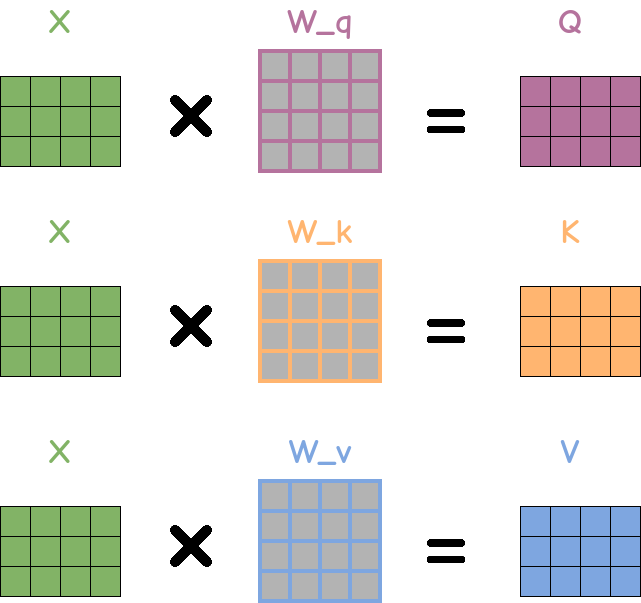

In [4]:
# 2) Create random weight matrices for Query, Key, and Value
W_q = torch.randn(embed_dim, embed_dim)   # shape (d, d)
W_k = torch.randn(embed_dim, embed_dim)   # shape (d, d)
W_v = torch.randn(embed_dim, embed_dim)   # shape (d, d)

print(f"W_q shape: {W_q.shape}")  # (d, d)
print(f"W_k shape: {W_k.shape}")  # (d, d)
print(f"W_v shape: {W_v.shape}")  # (d, d)
print()

# 3) Compute Q, K, V matrices
Q = X @ W_q    # shape (seq_len, d) # 🟧❓: This is equivalent to linear projection without bias
K = X @ W_k    # shape (seq_len, d)
V = X @ W_v    # shape (seq_len, d)
print(f"Q shape: {Q.shape}")  # (seq_len, d)
print(f"K shape: {K.shape}")  # (seq_len, d)
print(f"V shape: {V.shape}")  # (seq_len, d)

W_q shape: torch.Size([4, 4])
W_k shape: torch.Size([4, 4])
W_v shape: torch.Size([4, 4])

Q shape: torch.Size([3, 4])
K shape: torch.Size([3, 4])
V shape: torch.Size([3, 4])


---

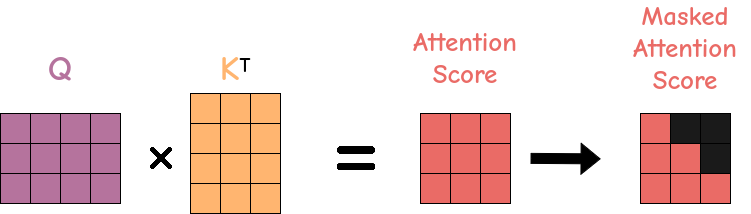

In [5]:
# 4) Compute attention scores
# Attention scores = Q @ K^T
attn_scores = Q @ K.T    # shape (seq_len, seq_len)
print(f"Attention scores shape: {attn_scores.shape} with values:\n{attn_scores}")  # (seq_len, seq_len)
print()

# Masked attention scores (for causal attention)
mask = torch.tril(torch.ones(seq_len, seq_len))  # Lower triangular mask
masked_attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
print(f"Masked attention scores shape: {masked_attn_scores.shape} with values:\n{masked_attn_scores}")  # (seq_len, seq_len)

# 🟧❓ Questions: 
# input = ['dog', 'chases', 'ball']
# - What does the entry `attn_scores[i, j]` mean in words? Ans: how much token at position i should pay attention to token at position j
# - In a decoder (causal) setting, why is it important that position t
#   cannot attend to positions > t?

Attention scores shape: torch.Size([3, 3]) with values:
tensor([[ 7.4223,  6.7085,  7.5645],
        [-4.2954, -2.7265,  0.3765],
        [-0.5024, -0.2675, -1.9349]])

Masked attention scores shape: torch.Size([3, 3]) with values:
tensor([[ 7.4223,    -inf,    -inf],
        [-4.2954, -2.7265,    -inf],
        [-0.5024, -0.2675, -1.9349]])


---



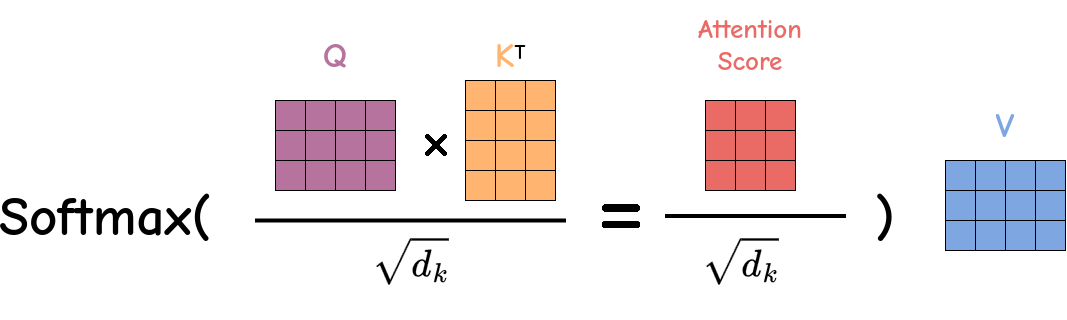
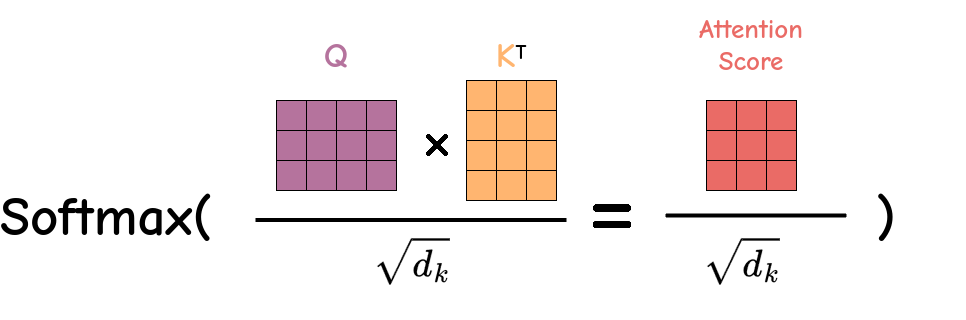

In [6]:
# 5) Softmax on scaled attention scores (or masked model) to get attention weights
d_k = K.shape[-1]  # dimension of keys
scaled_attn_scores = masked_attn_scores / (d_k ** 0.5)
print(f"Normal masked attention scores shape: {masked_attn_scores.shape} with values:\n{masked_attn_scores}")  # (seq_len, seq_len)
print(f"Scaled attention scores shape: {scaled_attn_scores.shape} with values:\n{scaled_attn_scores}")  # (seq_len, seq_len)
print()

# Apply softmax on last dimension (key dim) to get attention weights
attn_weights = scaled_attn_scores.softmax(dim=-1) 
print(f"Attention weights shape: {attn_weights.shape} with values:\n{attn_weights}")  # (seq_len, seq_len)
print()

# Multiply by V to get final output
output = attn_weights @ V    # shape (seq_len, d)
print(f"Output shape: {output.shape} with values:\n{output}")  # (seq_len, d)

# 🟧❓ Questions: 
# - Why do we scale the attention scores by sqrt(d_k)? (Hint: dimension of queries/keys affects dot product magnitude)
# - What should be the sum of each row of the attention weights matrix? Why?

Normal masked attention scores shape: torch.Size([3, 3]) with values:
tensor([[ 7.4223,    -inf,    -inf],
        [-4.2954, -2.7265,    -inf],
        [-0.5024, -0.2675, -1.9349]])
Scaled attention scores shape: torch.Size([3, 3]) with values:
tensor([[ 3.7112,    -inf,    -inf],
        [-2.1477, -1.3632,    -inf],
        [-0.2512, -0.1337, -0.9674]])

Attention weights shape: torch.Size([3, 3]) with values:
tensor([[1.0000, 0.0000, 0.0000],
        [0.3134, 0.6866, 0.0000],
        [0.3827, 0.4304, 0.1870]])

Output shape: torch.Size([3, 4]) with values:
tensor([[ 1.1163, -0.2890,  0.7274, -1.9395],
        [ 0.8194,  1.4147, -0.1188, -1.2083],
        [ 0.4516,  1.4227, -0.2449, -1.3991]])


# 2. Implementation of a tiny Transformer model


<img src="https://res.cloudinary.com/edlitera/image/upload/c_fill,f_auto/v1680629118/blog/gz5ccspg3yvq4eo6xhrr" alt="image.png" width="200"/>

We are now going to implement a tiny transformer without **masking** (in the above image it is the *decoder model*) model from scratch using PyTorch:
- Create the **Scaled Dot-Product Attention** module
- Create the **Multi-Head Attention** module
- Create the **Transformer Block** module (sometimes called *decoder* or *encoder* block depending if mask is used)
- Create the **Transformer Model** module

---
Do not hesitate to use `torch.reshape`, `torch.view` and `torch.transpose`to reshape tensors if needed!

## 2.1 Scaled Dot-Product Attention (Single Head Self-Attention) TODO)

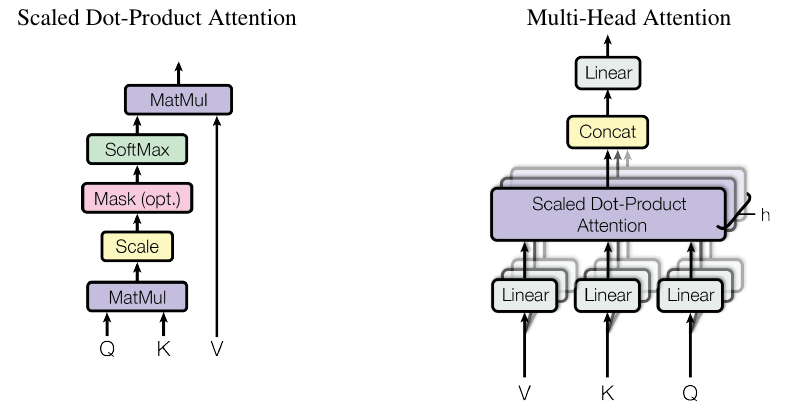

In [7]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: (batch, seq_len, d_head)
        mask: (batch, 1, seq_len, seq_len) or None
        returns: output (batch, seq_len, d_head) 
        """
        # TODO: implement scaled dot-product attention
        # 🟧 ❓ Hint: Because of batch size dimension, you may need to use broadcasting.
        # K.T for K = (seq_len, d_head) <-> K.transpose(-2, -1) for K = (batch, seq_len, d_head)
        d_k = K.shape[-1]
        scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
        
        if mask is not None:
            scores = scores.masked_fill(~mask.bool(), float("-inf"))
            
        attn_weights = F.softmax(scores, dim=-1) 
        output = attn_weights @ V
        return output
        # 1) scores = Q K^T / sqrt(d_head)
        # 2) softmax over 'key' dimension
        # 3) output = attention_weights @ V
        # 4) return output
        # optional: apply mask before softmax if mask is not None
        
    
batch, seq_len, d_head = 1, 4, 8
att = ScaledDotProductAttention()
Q = torch.randn(batch, seq_len, d_head)
K = torch.randn(batch, seq_len, d_head)
V = torch.randn(batch, seq_len, d_head)

out = att(Q, K, V)
print(f"Output shape: {out.shape}")  
# 🟧❓: If implemented correctly, what should be the output shape? 
# If we change batch_size to 4, what should be the output shape?

Output shape: torch.Size([1, 4, 8])


## 2.2 Multi-Head Self-Attention (TODO)

🟧 ❓ Why do we need multi-head attention?
- A single head learns only *one* way to compare tokens (i.e., one similarity space).
- Multiple heads allow the model to learn *different* ways to compare tokens (i.e., syntax, semantics, etc.).
- Example: The big brown dog quickly chased the small red ball yesterday.
    - Head 1: Focuses on subject-verb relationship (dog - chased)
    - Head 2: Focuses on verb-object relationship (chased - ball)
    - Head 3: Focuses on adjective information (dog with big - brown, ball with small - red)
    - etc ...



In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False) # learnable projection after concatenation for flexible mixing of heads

        self.attention = ScaledDotProductAttention()

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, 1, seq_len, seq_len) or None
        return: (batch, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape

        # TODO: Multi-head attention implementation
        # 1) Linear projections for Q, K, V (batch, seq_len, d_model)
        Q = self.W_q(x) 
        K = self.W_k(x)
        V = self.W_v(x)
        
        
        # 2) Reshape for multi-head attention in two steps 
            # 1st: (d_model -> num_heads, d_head) 
            # 2nd: transpose to (batch, num_heads, seq_len, d_head)
            # 🟧❓: Why do we need to reshape?
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_head).transpose(-2, -3)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_head).transpose(-2, -3)
            
        # 3) Apply ScaledDotProductAttention on each head
            # 🟧❓ Hint: Q, K, V have to be reshaped into (batch_size * num_heads, seq_len, d_head)
        output = self.attention(Q, K, V, mask)
          
        # 4) concat heads back to (batch, seq_len, d_model) and apply W_o
            # 🟧❓: Why do we need to apply W_o after concatenation? It is mainly to be in the same space as the original input d_model
        output = output.transpose(1,2)
        output = output.reshape(batch_size, seq_len, self.d_model)  
        
        out = self.W_o(output)
        return out
         


In [9]:
msa = MultiHeadSelfAttention(d_model=32, num_heads=4)
x = torch.randn(2, 10, 32)
out = msa(x) # Expected shape of out: (2, 10, 32)
out.shape

torch.Size([2, 10, 32])

## 2.3 Transformer Block (TODO)

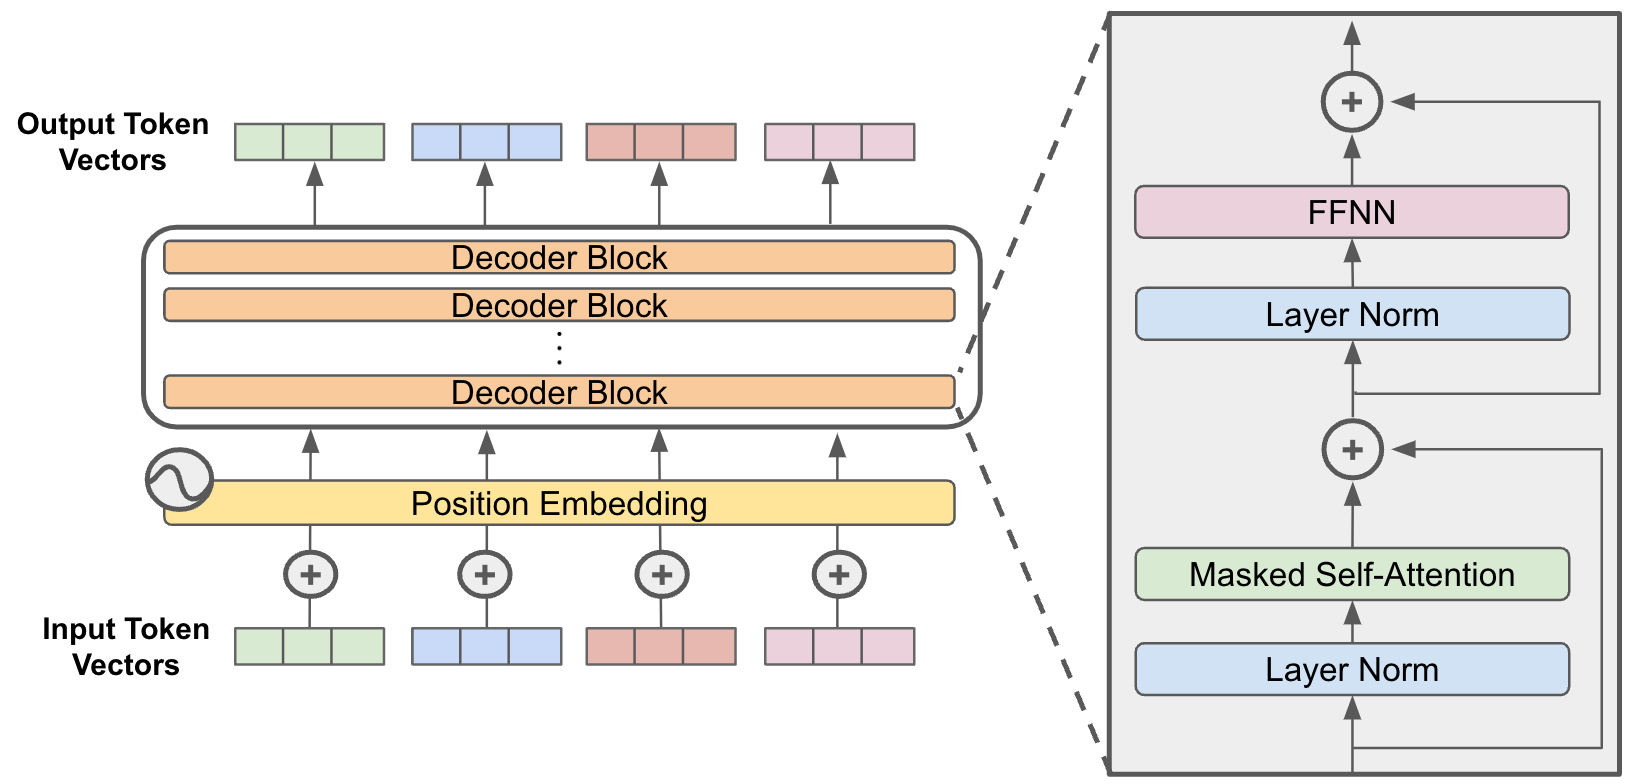


🟧❓: Here it is called decoder block because we are using the **masked attention** mechanism. If we were using the normal self-attention, it would be called an encoder block.

- MLP = Feed Forward Network = Fully Connected Network = store information  
- Residual Connections = Help gradients flow better during training  
- Layer Norm = Stabilize training  

----

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x, mask=None):
        # x: (batch, seq_len, d_model)
        # TODO: 1) layernorm + attention + residual
        out1 = self.attn(self.ln1(x)) + x
        # TODO: 2) layernorm + feedforward + residual
        out2 = self.ff(self.ln2(out1)) + out1
        return out2

## 2.4 A tiny Transformer model (TODO)

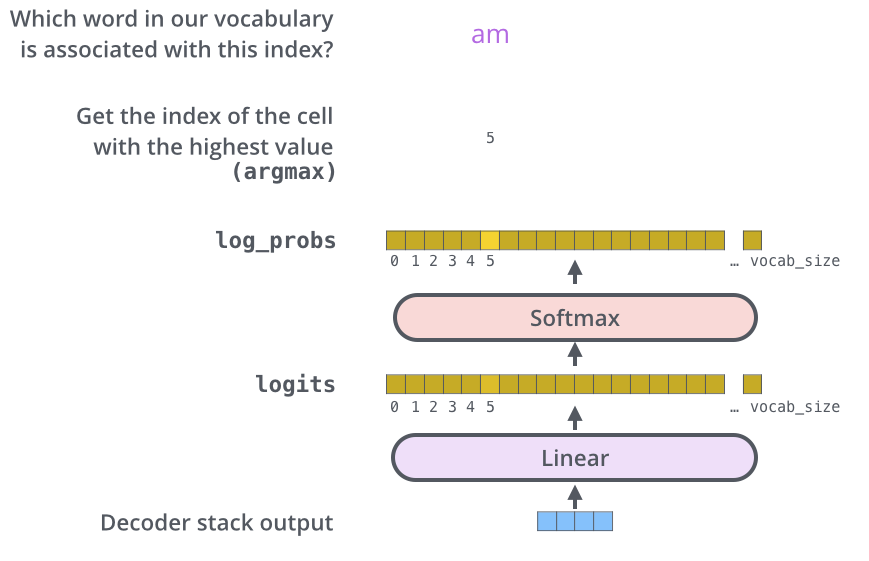

During **training**, we:
- Take these logits `(batch, seq_len, vocab_size)`
- Compare them to the ground-truth next tokens using `nn.CrossEntropyLoss`
- This loss internally applies `log_softmax` + negative log-likelihood, so we pass **raw logits**, not probabilities.

During **inference**, we:
- Often apply `softmax` to get probabilities
- Then use `argmax` or sampling (e.g. top-k, nucleus) to pick the next token.

🟧❓ Concept check:
- Why do we train on logits rather than explicitly normalised probabilities?
- In this tiny Transformer, what *exactly* does a single logit represent for a given position `t` and vocabulary id `v`?
---

In [11]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, d_ff=256, num_layers=2, max_len=128):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff)
            for _ in range(num_layers)
        ])
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.max_len = max_len

    def forward(self, idx):
        """
        idx: (batch, seq_len) integer token indices
        """
        batch_size, seq_len = idx.shape
        assert seq_len <= self.max_len
        mask = None # Optional: create a causal mask if needed
        # be careful with the shape of the mask
        
        # Token and positional embeddings are basically lookups here 
        token_emb = self.token_embedding(idx)  # (batch, seq_len, d_model)
        positions = torch.arange(seq_len, device=idx.device) # creates a tensor([0,1,...,seq_len-1])
        pos_emb = self.pos_embedding(positions)[None, :, :]  # (1, seq_len, d_model)
        
        # TODO: 1) add token and positional embeddings to get input x
        x = token_emb + pos_emb
        
        # TODO: 2) pass through transformer layers
        for layer in self.layers:
            out1 = layer(x, mask=None)
            
        # TODO: 3) linear head -> logits
        out2 = self.head(out1)
        
        return out2


# 3. Training our tiny Transformer (optional)

We will be using the French news dataset:
`wget https://olki.loria.fr/cerisara/lexres/frnews.txt`

If on colab, do not forget to switch on GPU runtime.

In [20]:
text = open("frnews.txt").read()

# Remove the date prefix from each line by keeping the text after the first colon.
text = "\n".join(
    line.split(":", 1)[1].strip()
    for line in text.splitlines()
    if ":" in line
)

chars = sorted(list(set(text)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)

def encode(s):  # string -> list[int]
    return [stoi[c] for c in s]

def decode(idx_list):  # list[int] -> string
    return "".join(itos[i] for i in idx_list)

data = torch.tensor(encode(text), dtype=torch.long) # basic character-level tokenization

block_size = 64  # context length

def get_batch(batch_size=32):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x, y

print(f"Dataset: {len(data):,} characters, vocabulary size: {vocab_size}")

Dataset: 1,811,510 characters, vocabulary size: 130


In [21]:
@torch.no_grad()
def generate(model, idx, max_new_tokens):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.max_len:]
        logits = model(idx_cond)
        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)
    return idx

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyTransformer(
    vocab_size=vocab_size,
    d_model=64,
    num_heads=4,
    d_ff=256,
    num_layers=2,
    max_len=block_size,
).to(device)

# Generate from the randomly initialized model before training.
start = torch.tensor([[stoi[text[0]]]], dtype=torch.long, device=device)
sample_idx = generate(model, start, max_new_tokens=100)[0].tolist()
print(decode(sample_idx))

UÂE|7qÂôPà 1:Rv8ñ​ù««z”=Ab“>îfv.ûêjl\ïÇQoj\SgVÎp3AoYRp
Nm,mèoà5K?“52z‎;êVPvTû²[a3ᵉ'dQ!b‘ÀbÀ²".:/6‘U5f


In [23]:
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

for step in range(501):
    x, y = get_batch(batch_size=32)
    x, y = x.to(device), y.to(device)

    logits = model(x)
    loss = loss_fn(logits.reshape(-1, vocab_size), y.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"step {step}: loss {loss.item():.3f}")


step 0: loss 5.177
step 50: loss 4.613
step 100: loss 3.824
step 150: loss 3.451
step 200: loss 3.190
step 250: loss 3.017
step 300: loss 3.074
step 350: loss 2.981
step 400: loss 2.845
step 450: loss 2.914
step 500: loss 2.786


In [24]:
# Evaluate after training
start = torch.tensor([[stoi[text[0]]]], dtype=torch.long, device=device)
sample_idx = generate(model, start, max_new_tokens=100)[0].tolist()
print(decode(sample_idx))

Unnn;e sf mar venioN peceé: decuuttea mOreut a poncuont fnGne Minn tonfe denaqhaé  éuon ls s à és Doe
